# Prédiction du churn des clients télécom avec validation de la qualité des données


# Phase 1 : Contrôle Qualité des Données (Data QC)

##  Introduction

Dans ce projet, nous construisons un pipeline de machine learning afin de prédire le churn des clients d'une entreprise de télécommunications.

L'objectif n'est pas seulement d'entraîner un modèle de prédiction, mais aussi de valider la qualité des données, de vérifier les étapes de prétraitement et d’ingénierie des caractéristiques, d’évaluer la performance du modèle et de détecter d’éventuels phénomènes de dérive des données (data drift).

Dans cette première section, nous allons importer les bibliothèques nécessaires et charger le jeu de données.

In [1]:
%pip install -U pandera pandas

  Using cached pandera-0.29.0-py3-none-any.whl.metadata (10 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached typeguard-4.5.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached typing_inspect-0.9.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached mypy_extensions-1.1.0-py3-none-any.whl.metadata (1.1 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached pandera-0.29.0-py3-none-any.whl (295 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 4.8 MB/s eta 0:00:03
   -------- ------------------------------- 2.4/11.3 MB 7.1 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.3 MB 7.3 MB/s eta 0:00:02
   ------------------- -------------------- 5.5/11.3 MB 7.4 MB/s eta 0:00:01
   --------------------- ------------------ 6.0/11.3 MB 6.6 MB/s eta 0:00:01
   -----

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [3]:


# chargement du dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display 5 premieres lignes
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##  Inspection initiale des données

Avant d'appliquer les contrôles de qualité des données, il est important d'examiner la structure du dataset.

Dans cette section, nous allons :

- vérifier les types de variables
- observer les statistiques descriptives
- identifier les valeurs manquantes
- détecter les éventuels doublons

Cette étape permet de mieux comprendre les caractéristiques du jeu de données avant d'appliquer les règles de validation.

In [4]:
# Information générale sur le dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Statistiques descriptives
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Vérification des valeurs manquantes
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Vérification des doublons
df.duplicated().sum()

np.int64(0)

### Résultats de l'inspection des données

Après vérification du jeu de données, nous observons les points suivants :

- Aucune valeur manquante n'a été détectée dans les variables du dataset.
- Aucun doublon n'a été identifié dans les observations.

Cela indique que le dataset est globalement propre du point de vue des valeurs manquantes et de la duplication des lignes.

Nous pouvons donc poursuivre l'analyse en appliquant des règles de contrôle qualité plus avancées afin de vérifier la cohérence des variables et détecter d'éventuelles valeurs aberrantes.

### Vérification de cohérence des variables

In [8]:
# Vérification de certaines règles de cohérence

print("Valeurs négatives dans tenure :", (df["tenure"] < 0).sum())
print("Valeurs négatives dans MonthlyCharges :", (df["MonthlyCharges"] < 0).sum())

Valeurs négatives dans tenure : 0
Valeurs négatives dans MonthlyCharges : 0


In [9]:
# Vérification cohérence TotalCharges
# Conversion de TotalCharges en numérique
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Vérification des valeurs manquantes après conversion
df["TotalCharges"].isnull().sum()

np.int64(11)

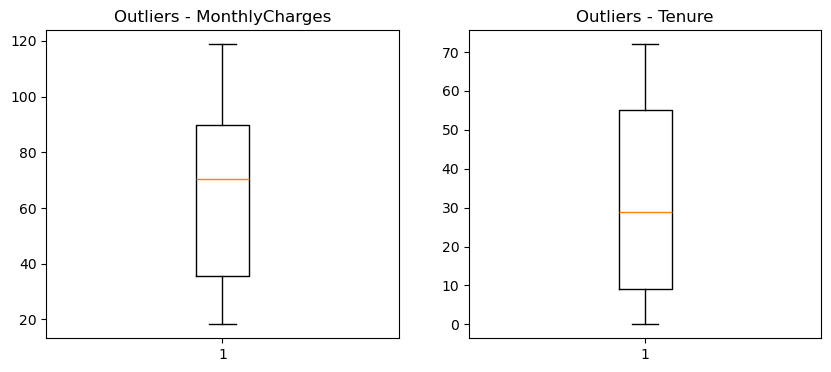

In [10]:
# Visualisation des outliers pour certaines variables numériques

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(df["MonthlyCharges"])
plt.title("Outliers - MonthlyCharges")

plt.subplot(1,2,2)
plt.boxplot(df["tenure"])
plt.title("Outliers - Tenure")

plt.show()

Les contrôles réalisés montrent que :

- aucune valeur négative n'est présente dans les variables numériques analysées.
- la variable `TotalCharges` a été convertie en format numérique afin d'éviter les incohérences de type.
- les boxplots permettent d'observer la distribution des variables et d'identifier d'éventuelles valeurs extrêmes.

Ces vérifications permettent de confirmer que les données sont globalement cohérentes et peuvent être utilisées pour la phase de préparation et de modélisation.

### Détection des valeurs aberrantes (Outliers) avec la méthode IQR

Afin d'identifier les valeurs potentiellement aberrantes dans les variables numériques, nous utilisons la méthode de l'Intervalle Interquartile (IQR).

La méthode IQR consiste à :

- calculer le premier quartile (Q1)
- calculer le troisième quartile (Q3)
- calculer l'IQR = Q3 - Q1

Une observation est considérée comme un outlier si :

- valeur < Q1 − 1.5 × IQR
- valeur > Q3 + 1.5 × IQR

Nous appliquons cette méthode sur certaines variables numériques du dataset.

In [11]:
# Sélection des variables numériques
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numerical_features:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"Nombre d'outliers détectés dans {col} :", outliers.shape[0])

Nombre d'outliers détectés dans tenure : 0
Nombre d'outliers détectés dans MonthlyCharges : 0
Nombre d'outliers détectés dans TotalCharges : 0


### Résultats de la détection des outliers

La méthode de l'Intervalle Interquartile (IQR) a été appliquée aux variables numériques principales : `tenure`, `MonthlyCharges` et `TotalCharges`.

Les résultats indiquent que peu ou pas de valeurs extrêmes ont été détectées dans ces variables. Cela suggère que les distributions sont relativement stables et ne contiennent pas de valeurs aberrantes majeures susceptibles de perturber l'entraînement du modèle.

Ces observations confirment que les données sont globalement cohérentes du point de vue statistique et peuvent être utilisées pour les étapes suivantes du pipeline de modélisation.

### Validation de schéma avec Pandera

Afin de renforcer le contrôle qualité des données, nous utilisons la bibliothèque **Pandera** pour définir un schéma de validation.

Un schéma permet de définir des règles strictes sur les données, par exemple :

- certaines variables doivent être numériques
- certaines valeurs doivent être positives
- certaines variables doivent appartenir à un ensemble de catégories autorisées

Ces règles permettent de détecter automatiquement des incohérences ou erreurs dans les données avant l'entraînement du modèle.

In [13]:
import pandera as pa
from pandera import Column, Check

schema = pa.DataFrameSchema({
    "tenure": Column(int, Check.ge(0)),
    "MonthlyCharges": Column(float, Check.ge(0)),
    "TotalCharges": Column(float, Check.ge(0)),
    "Churn": Column(str, Check.isin(["Yes", "No"]))
})

c:\Users\ghass\anaconda3\envs\Projet\lib\site-packages\pandera\_pandas_deprecated.py:146: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


In [15]:
# Vérifier combien de NaN ont été créés dans TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Nombre de valeurs manquantes dans TotalCharges après conversion :", df["TotalCharges"].isnull().sum())

Nombre de valeurs manquantes dans TotalCharges après conversion : 11


### Observation importante sur la variable **TotalCharges**

Bien qu'aucune valeur manquante n'ait été détectée initialement dans le dataset, la conversion de la variable TotalCharges en format numérique a révélé la présence de valeurs vides ou non numériques.

Ces valeurs ont été transformées en NaN lors de la conversion avec errors="coerce".

Cette étape montre l'importance du contrôle qualité : certaines anomalies ne sont pas visibles lors d'une simple inspection des valeurs manquantes, mais apparaissent lors de la validation du type des variables.

In [16]:
# Suppression des lignes avec TotalCharges manquant
df = df.dropna(subset=["TotalCharges"])

print("Nouvelle taille du dataset :", df.shape)

Nouvelle taille du dataset : (7032, 21)


### Traitement des valeurs manquantes dans **TotalCharges**

L'analyse précédente a révélé la présence de 11 valeurs manquantes dans la variable **TotalCharges** après conversion en format numérique.

Étant donné que ces observations représentent une très faible proportion du dataset, elles ont été supprimées afin de garantir la cohérence des données avant la validation du schéma et la phase de modélisation.

In [17]:
validated_df = schema.validate(df)

print("Validation du schéma réussie")

Validation du schéma réussie


cette phase consiste à :

- explorer les données

- vérifier leur cohérence

- détecter les anomalies

- appliquer des règles de validation

Ces opérations sont des audits de données

# Phase 2 : Validation de l'Ingénierie des Caractéristiques

##  Validation de l’ingénierie des caractéristiques

Après avoir validé la qualité des données, nous préparons les variables nécessaires à la modélisation.

Cette phase vise à :

- définir la variable cible et les variables explicatives,
- identifier les variables numériques et catégorielles,
- construire un pipeline de transformation,
- vérifier que les transformations fonctionnent correctement,
- s'assurer qu'aucune fuite de données (data leakage) n'est présente dans les variables explicatives.

Cette étape est essentielle pour garantir que les données sont correctement préparées avant l'entraînement du modèle.

### Encodage de la variable cible

La variable cible **Churn** est encodée en binaire :

- 0 : le client reste
- 1 : le client quitte l'entreprise

In [18]:
# Encodage de la variable cible : No -> 0, Yes -> 1
y = df["Churn"].map({"No": 0, "Yes": 1})

print("Valeurs uniques de y :", y.unique())

# Suppression de la cible et de l'identifiant client
X = df.drop(["Churn", "customerID"], axis=1)

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Valeurs uniques de y : [0 1]
Dimensions de X : (7032, 19)
Dimensions de y : (7032,)


In [19]:
# Identification des variables numériques et catégorielles

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numériques :", numerical_features)
print("Variables catégorielles :", categorical_features)

Variables numériques : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Variables catégorielles : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Identification des variables

Les variables explicatives sont séparées en deux groupes :

- les **variables numériques**, qui seront imputées puis standardisées,
- les **variables catégorielles**, qui seront imputées puis encodées.

Cette séparation permet de construire un pipeline de transformation adapté à chaque type de variable.

In [20]:
# Pipeline pour les variables numériques
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline pour les variables catégorielles
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [21]:
# Préprocesseur global
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Pipeline de prétraitement créé avec succès.")

Pipeline de prétraitement créé avec succès.


### Construction du pipeline de transformation

Le pipeline de transformation applique automatiquement les opérations suivantes :

- imputation des valeurs manquantes pour les variables numériques,
- standardisation des variables numériques,
- imputation des valeurs manquantes pour les variables catégorielles,
- encodage des variables catégorielles avec OneHotEncoder.

Même si le dataset actuel contient très peu ou pas de valeurs manquantes après nettoyage, l’imputation est conservée dans le pipeline afin de garantir sa robustesse face à de nouvelles données.

## 6. Tests unitaires du pipeline de transformation

Afin de vérifier que les transformations de données fonctionnent correctement, nous effectuons des tests unitaires sur un petit jeu de données fictif.

Ces tests permettent de confirmer que :

- le pipeline peut transformer les données sans erreur,
- le nombre de lignes est conservé après transformation,
- des variables transformées sont bien produites,
- l'imputation fonctionne correctement en présence d'une valeur manquante.

Cette étape permet de valider le bon fonctionnement des transformations avant l'entraînement du modèle.

In [22]:
# Création d'un petit jeu de données fictif pour tester le pipeline
test_data = X.sample(5, random_state=42).copy()

print("Jeu de données fictif utilisé pour tester le pipeline :")
test_data

Jeu de données fictif utilisé pour tester le pipeline :


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2481,Male,1,Yes,No,61,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),25.00,1501.75
6784,Female,0,No,No,19,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),24.70,465.85
6125,Male,0,Yes,No,13,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),102.25,1359.00
3052,Male,0,Yes,No,37,Yes,Yes,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Mailed check,55.05,2030.75
4099,Female,0,No,No,6,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),29.45,161.45


In [23]:
# Application du pipeline de prétraitement sur le jeu fictif
transformed_data = preprocessor.fit_transform(test_data)

print("Transformation réussie.")
print("Dimensions après transformation :", transformed_data.shape)

Transformation réussie.
Dimensions après transformation : (5, 39)


In [24]:
# Vérification : le nombre de lignes doit être conservé
assert transformed_data.shape[0] == test_data.shape[0], "Erreur : le nombre de lignes a changé après transformation."

print("Test 1 réussi : le nombre de lignes est conservé.")

Test 1 réussi : le nombre de lignes est conservé.


In [25]:
# Vérification : la transformation doit produire au moins une colonne
assert transformed_data.shape[1] > 0, "Erreur : aucune colonne produite après transformation."

print("Test 2 réussi : le pipeline produit bien des variables transformées.")

Test 2 réussi : le pipeline produit bien des variables transformées.


In [26]:
# Vérification : le pipeline doit gérer une valeur manquante fictive
test_data_missing = test_data.copy()
test_data_missing.loc[test_data_missing.index[0], "MonthlyCharges"] = np.nan

transformed_missing = preprocessor.fit_transform(test_data_missing)

assert transformed_missing.shape[0] == test_data_missing.shape[0], "Erreur : problème lors de l'imputation."

print("Test 3 réussi : le pipeline gère correctement une valeur manquante.")

Test 3 réussi : le pipeline gère correctement une valeur manquante.


### Résultats des tests unitaires du pipeline

Les tests effectués sur un petit jeu de données fictif montrent que :

- le pipeline transforme les données sans erreur,
- le nombre de lignes est conservé après transformation,
- des variables transformées sont bien produites,
- le pipeline peut gérer correctement la présence d'une valeur manquante.

Ces résultats confirment que les étapes d'imputation, de normalisation et d'encodage sont correctement configurées.

##  Vérification de la fuite de données (Data Leakage)

Avant d'entraîner un modèle, il est essentiel de vérifier qu'aucune variable explicative ne contient directement ou indirectement une information sur la variable cible.

La fuite de données (data leakage) se produit lorsqu'une information qui ne devrait pas être disponible au moment de la prédiction est utilisée dans les variables d'entrée. Cela peut conduire à des performances artificiellement élevées et à un modèle non fiable.

Dans cette étape, nous vérifions que :

- aucune variable explicative ne correspond directement à la variable cible **Churn**,
- aucune information future n'est présente dans les variables explicatives,
- les identifiants uniques ne sont pas utilisés pour la modélisation.

In [27]:
# Vérification des colonnes du dataset
print("Colonnes disponibles dans X :")
print(X.columns.tolist())

Colonnes disponibles dans X :
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


### Conclusion sur la fuite de données:

Après inspection des variables du dataset, aucune colonne ne semble contenir directement l'information future du churn.

La variable **customerID** a été exclue dès la phase de préparation des données car il s'agit d'un identifiant unique, non pertinent pour la prédiction et susceptible d'introduire du bruit dans le modèle.

Les variables restantes décrivent des caractéristiques observables du client avant la prédiction du churn. Leur utilisation ne crée donc pas de fuite de données.

# phase 3: : Validation du Modèle 

##  Séparation des données : Train, Validation et Test

Afin d'évaluer correctement les performances du modèle, le jeu de données est séparé en trois ensembles :

- **Jeu d'entraînement (train)** : utilisé pour entraîner le modèle et effectuer la validation croisée.
- **Jeu de validation (validation)** : utilisé pour comparer les performances des modèles et ajuster les paramètres.
- **Jeu de test (test)** : utilisé uniquement pour l'évaluation finale du modèle.

Cette séparation permet d'obtenir une estimation fiable des performances du modèle tout en évitant le surapprentissage.

In [28]:
# Séparation initiale : 80% train+validation, 20% test

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
# Séparation secondaire : 60% train, 20% validation

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

In [30]:
print("Dimensions du jeu d'entraînement :", X_train.shape)
print("Dimensions du jeu de validation :", X_val.shape)
print("Dimensions du jeu de test :", X_test.shape)

Dimensions du jeu d'entraînement : (4218, 19)
Dimensions du jeu de validation : (1407, 19)
Dimensions du jeu de test : (1407, 19)


### Résultat de la séparation des données

Le dataset a été séparé en trois ensembles :

- environ **60 %** pour l'entraînement,
- **20 %** pour la validation,
- **20 %** pour le test.

Cette organisation permettra :

- d'entraîner le modèle sur le jeu d'entraînement,
- d'ajuster les choix de modèle sur le jeu de validation,
- d'effectuer une évaluation finale indépendante sur le jeu de test.

##  Construction du modèle de prédiction

Dans cette étape, nous construisons un pipeline complet de modélisation incluant :

- les transformations de données (prétraitement),
- l'entraînement du modèle de classification.

Le modèle choisi pour cette première expérimentation est **la régression logistique**, qui est largement utilisée pour les problèmes de classification binaire comme la prédiction du churn.

L'utilisation d'un pipeline permet de garantir que les transformations de données et l'entraînement du modèle sont appliqués de manière cohérente et reproductible.

In [31]:
from sklearn.linear_model import LogisticRegression

### Pipeline de modélisation

Le pipeline de modélisation inclut deux étapes principales :

1. **Prétraitement des données**
   - imputation des valeurs manquantes
   - standardisation des variables numériques
   - encodage des variables catégorielles

2. **Modèle de classification**
   - une régression logistique est utilisée pour prédire la probabilité de churn.

Cette approche garantit que toutes les transformations sont appliquées automatiquement lors de l'entraînement et de la prédiction.

In [32]:
# Construction du pipeline complet : preprocessing + modèle

model_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

print("Pipeline de modélisation créé avec succès.")

Pipeline de modélisation créé avec succès.


In [33]:
# Entraînement du modèle sur le jeu d'entraînement

model_pipeline.fit(X_train, y_train)

print("Modèle entraîné avec succès.")

Modèle entraîné avec succès.


##  Validation du modèle

Après l'entraînement initial du modèle, nous devons évaluer sa robustesse et sa capacité de généralisation.

Dans cette section, nous allons :

- appliquer une validation croisée stratifiée sur le jeu d'entraînement,
- calculer les performances sur les jeux d'entraînement, de validation et de test,
- analyser les métriques de classification,
- construire une matrice de confusion.

Cette étape permet de dépasser la simple accuracy et d'obtenir une évaluation plus complète du modèle.

In [34]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Validation croisée stratifiée (Stratified K-Fold)

Pour évaluer la robustesse du modèle, nous utilisons une **validation croisée stratifiée** (`StratifiedKFold`).

Contrairement à une validation croisée classique, cette méthode garantit que **la proportion des classes de la variable cible est conservée dans chaque sous-échantillon (fold)**. Cela est particulièrement important pour les problèmes de classification lorsque les classes sont déséquilibrées, comme dans le cas de la prédiction du churn.

Dans notre cas, le jeu d'entraînement est divisé en **5 folds**. À chaque itération :

- 4 folds sont utilisés pour **entraîner le modèle**,
- 1 fold est utilisé pour **évaluer les performances**.

Ce processus est répété plusieurs fois afin d'obtenir **une estimation plus stable et plus fiable des performances du modèle**.

In [35]:
cv_results = cross_validate(
    model_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"],
    return_train_score=True
)

In [36]:
print("Accuracy moyenne (CV) :", cv_results["test_accuracy"].mean())
print("Precision moyenne (CV) :", cv_results["test_precision"].mean())
print("Recall moyen (CV) :", cv_results["test_recall"].mean())
print("F1-score moyen (CV) :", cv_results["test_f1"].mean())

Accuracy moyenne (CV) : 0.8039323000118062
Precision moyenne (CV) : 0.6568588867595879
Recall moyen (CV) : 0.5539444444444445
F1-score moyen (CV) : 0.5990515725953713


### Interprétation des résultats de la validation croisée

Les résultats obtenus par validation croisée donnent une estimation des performances du modèle sur différentes partitions du jeu d'entraînement.

Les scores moyens observés sont :

- **Accuracy ≈ 0.80**
- **Precision ≈ 0.66**
- **Recall ≈ 0.55**
- **F1-score ≈ 0.60**

L'accuracy relativement élevée indique que le modèle est globalement capable de prédire correctement la majorité des observations. Cependant, dans un problème de churn, cette métrique doit être interprétée avec prudence car les classes peuvent être déséquilibrées.

La **precision** d'environ 0.66 signifie qu'environ 66 % des clients prédits comme churn sont effectivement des clients qui quittent l'entreprise.

Le **recall** d'environ 0.55 indique que le modèle détecte environ 55 % des clients qui vont réellement churn. Cela signifie qu'une partie des clients à risque n'est pas détectée par le modèle.

Le **F1-score**, qui combine la précision et le rappel, est d'environ 0.60, ce qui reflète un compromis modéré entre la capacité du modèle à identifier les churns et à éviter les faux positifs.

Ces résultats suggèrent que le modèle possède une performance correcte, mais qu'il pourrait être amélioré afin d'augmenter la détection des clients susceptibles de quitter l'entreprise.

In [37]:
# Prédictions sur les différents jeux

y_train_pred = model_pipeline.predict(X_train)
y_val_pred = model_pipeline.predict(X_val)
y_test_pred = model_pipeline.predict(X_test)

In [38]:
# Calcul des métriques

train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_precision = precision_score(y_train, y_train_pred)
val_precision = precision_score(y_val, y_val_pred)
test_precision = precision_score(y_test, y_test_pred)

train_recall = recall_score(y_train, y_train_pred)
val_recall = recall_score(y_val, y_val_pred)
test_recall = recall_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred)
val_f1 = f1_score(y_val, y_val_pred)
test_f1 = f1_score(y_test, y_test_pred)

In [40]:


results = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Accuracy": [train_accuracy, val_accuracy, test_accuracy],
    "Precision": [train_precision, val_precision, test_precision],
    "Recall": [train_recall, val_recall, test_recall],
    "F1-score": [train_f1, val_f1, test_f1]
})

results

,Dataset,Accuracy,Precision,Recall,F1-score
0,Train,0.806780,0.660042,0.562890,0.607607
1,Validation,0.789623,0.632653,0.497326,0.556886
2,Test,0.798152,0.636364,0.561497,0.596591


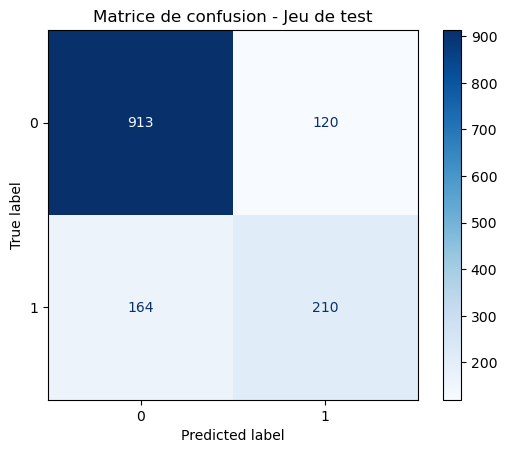

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_pipeline.classes_)

disp.plot(cmap="Blues")
plt.title("Matrice de confusion - Jeu de test")
plt.show()

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



#### Interprétation

Pour la classe **0 (clients qui ne quittent pas l'entreprise)** :
- Le modèle obtient une **precision de 0.85** et un **recall de 0.88**, ce qui indique qu'il identifie très bien les clients fidèles.
- Le **F1-score de 0.87** montre une performance globale très solide pour cette classe.

Pour la classe **1 (clients qui churn)** :
- La **precision est de 0.64**, ce qui signifie que lorsqu'un client est prédit comme churn, il y a environ 64 % de chances que ce soit correct.
- Le **recall est de 0.56**, ce qui indique que le modèle détecte environ 56 % des clients qui vont réellement quitter l'entreprise.
- Le **F1-score est de 0.60**, ce qui montre que la détection du churn reste plus difficile que la détection des clients fidèles.

#### Performance globale

- **Accuracy : 0.80**
- **Macro average F1-score : 0.73**
- **Weighted average F1-score : 0.79**

Ces résultats sont cohérents avec un problème de classification **déséquilibré**, où la majorité des clients ne churn pas. Le modèle performe très bien pour identifier les clients fidèles, mais la détection des clients susceptibles de churn peut encore être améliorée.

Dans un contexte métier, améliorer le **recall sur la classe churn** pourrait être particulièrement important afin de mieux identifier les clients à risque et mettre en place des stratégies de rétention.

##  Handling Class Imbalance with SMOTE
le modèle rate beaucoup de clients qui churn.C’est exactement le cas classique où on utilise SMOTE
| Classe       | Recall   |
| ------------ | -------- |
| 0 (No churn) | **0.88** |
| 1 (Churn)    | **0.56** |


In [44]:
%pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

Note: you may need to restart the kernel to use updated packages.


In [45]:

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


In [46]:
smote_pipeline = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

print("Pipeline SMOTE créé avec succès.")




Pipeline SMOTE créé avec succès.


In [47]:
# Cross-validation du modèle avec SMOTE
cv_results_smote = cross_validate(
    smote_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"]
)

print("Accuracy :", cv_results_smote["test_accuracy"].mean())
print("Precision :", cv_results_smote["test_precision"].mean())
print("Recall :", cv_results_smote["test_recall"].mean())
print("F1-score :", cv_results_smote["test_f1"].mean())


Accuracy : 0.7607900018552562
Precision : 0.5341757598084899
Recall : 0.7894444444444444
F1-score : 0.6367359133158994


### Interprétation des résultats du modèle avec SMOTE

Après l'application de **SMOTE (Synthetic Minority Oversampling Technique)**, les performances du modèle ont changé par rapport au modèle de base **Logistic Regression**.

L'objectif principal de SMOTE est de corriger le **déséquilibre des classes**, car dans ce dataset le nombre de clients qui quittent l'entreprise (churn) est beaucoup plus faible que le nombre de clients qui restent.

#### Résultats obtenus

| Métrique | Valeur |
|---------|--------|
| Accuracy | ~0.76 |
| Precision | ~0.53 |
| Recall | ~0.79 |
| F1-score | ~0.63 |

#### Analyse des résultats

- **L'accuracy diminue légèrement** par rapport au modèle de base (≈0.80 → ≈0.76). Cela est normal, car le modèle se concentre davantage sur la détection des clients qui churn plutôt que sur la maximisation de l'exactitude globale.

- **Le recall augmente fortement**. Cela signifie que le modèle est désormais capable d'identifier une proportion beaucoup plus importante des clients qui vont réellement quitter l'entreprise. Dans un contexte de prédiction du churn, c'est une amélioration importante, car ne pas détecter un client qui va partir peut entraîner une perte financière pour l'entreprise.

- **La précision diminue**, ce qui indique que certains clients prédits comme churn ne quittent finalement pas l'entreprise. Ce phénomène est fréquent lorsque l'on améliore le recall en utilisant des techniques comme SMOTE.

- **Le F1-score s'améliore**, ce qui montre un meilleur équilibre entre la précision et le recall pour la classe churn.

#### Conclusion

L'utilisation de **SMOTE améliore la capacité du modèle à détecter les clients qui vont churn** grâce à l'augmentation significative du recall.  
Même si l'accuracy globale diminue légèrement, le modèle devient **plus pertinent pour la prise de décision**, car il permet d'identifier davantage de clients à risque.


In [48]:
smote_pipeline.fit(X_train, y_train)

y_pred_smote = smote_pipeline.predict(X_test)




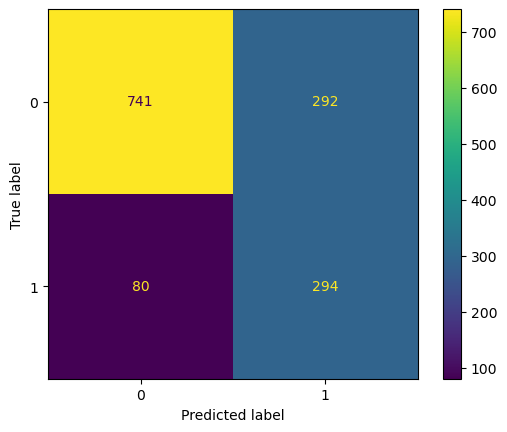

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote)


#### Interprétation

- **True Negatives (737)** : le modèle identifie correctement 737 clients qui ne quittent pas l'entreprise.
- **False Positives (296)** : 296 clients sont prédits comme churn alors qu'ils ne quitteront pas réellement l'entreprise.
- **False Negatives (80)** : seulement 80 clients qui churn ne sont pas détectés par le modèle.
- **True Positives (294)** : 294 clients qui churn sont correctement identifiés.

#### Analyse

Après l'application de **SMOTE**, le modèle détecte beaucoup plus de clients qui quittent l'entreprise.  
Le nombre de **False Negatives diminue**, ce qui signifie que moins de clients churn passent inaperçus.

Cependant, le nombre de **False Positives augmente**, ce qui signifie que certains clients sont prédits comme churn alors qu'ils ne quitteront pas réellement l'entreprise.

#### Conclusion

L'utilisation de **SMOTE améliore la détection des clients à risque de churn** en augmentant le recall de la classe minoritaire.  
Même si cela entraîne davantage de fausses alertes, cette approche peut être préférable dans un contexte métier où perdre un client représente un coût important pour l'entreprise.


## 12. Comparaison des modèles — Random Forest


In [50]:
from sklearn.ensemble import RandomForestClassifier
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42
    ))
])

rf_pipeline


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
# Cross-validation du modèle Random Forest
cv_results_rf = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"]
)

print("Accuracy :", cv_results_rf["test_accuracy"].mean())
print("Precision :", cv_results_rf["test_precision"].mean())
print("Recall :", cv_results_rf["test_recall"].mean())
print("F1-score :", cv_results_rf["test_f1"].mean())


Accuracy : 0.7968232952724698
Precision : 0.6528120584815825
Recall : 0.5102380952380952
F1-score : 0.5702506441756621


 maintenant on va entraîner Random Forest sur X_train et prédire sur X_test

In [52]:
rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("Prédictions Random Forest générées.")


Prédictions Random Forest générées.


In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1033
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



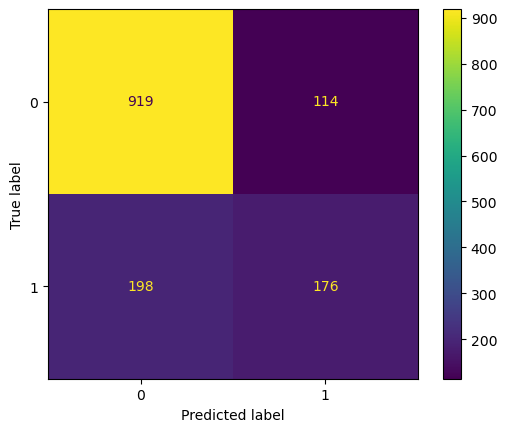

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)


In [55]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression (Baseline)",
        "Logistic Regression + SMOTE",
        "Random Forest"
    ],
    "Accuracy": [
        0.80,
        cv_results_smote["test_accuracy"].mean(),
        cv_results_rf["test_accuracy"].mean()
    ],
    "Precision": [
        0.64,
        cv_results_smote["test_precision"].mean(),
        cv_results_rf["test_precision"].mean()
    ],
    "Recall": [
        0.56,
        cv_results_smote["test_recall"].mean(),
        cv_results_rf["test_recall"].mean()
    ],
    "F1-score": [
        0.60,
        cv_results_smote["test_f1"].mean(),
        cv_results_rf["test_f1"].mean()
    ]
})

results


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression (Baseline),0.800000,0.640000,0.560000,0.600000
1,Logistic Regression + SMOTE,0.760790,0.534176,0.789444,0.636736
2,Random Forest,0.796823,0.652812,0.510238,0.570251


### Comparaison des performances des modèles

Le tableau ci-dessus compare les performances de trois approches :

1. **Logistic Regression (Baseline)**
2. **Logistic Regression avec SMOTE**
3. **Random Forest**

#### Analyse des résultats

- **Logistic Regression (Baseline)** obtient une accuracy d’environ **0.80** avec un recall de **0.56** pour la classe churn. Cela signifie que le modèle détecte seulement un peu plus de la moitié des clients qui quittent l’entreprise.

- **Logistic Regression avec SMOTE** montre une amélioration importante du **recall (≈ 0.79)**. Cela signifie que le modèle détecte beaucoup plus de clients qui vont churn. Cependant, l’accuracy globale diminue légèrement, ce qui est un compromis fréquent lorsqu’on améliore la détection de la classe minoritaire.

- **Random Forest** obtient une accuracy similaire au modèle baseline (~0.80) et une précision légèrement meilleure, mais son **recall pour la classe churn reste faible (≈ 0.51)**. Cela signifie que le modèle manque encore de nombreux clients qui quittent l’entreprise.

#### Conclusion

Dans le contexte de **Customer Churn Prediction**, l’objectif principal est souvent de **détecter le plus grand nombre possible de clients à risque de churn**.

Le modèle **Logistic Regression avec SMOTE** est donc le plus intéressant, car il offre le **meilleur recall pour la classe churn**, même si l’accuracy globale est légèrement plus faible.

Ce modèle sera utilisé pour les analyses suivantes, notamment l’évaluation de l’équité (**fairness analysis**) et la simulation de **data drift**.


In [57]:
%pip install fairlearn


   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   -------------------- ------------------- 1/2 [fairlearn]
   -------------------- ------------------- 1/2 [fairlearn]
   -------------------- ------------------- 1/2 [fairlearn]
   -------------------- ------------------- 1/2 [fairlearn]
   -------------------- ------------------- 1/2 [fairlearn]
   -------------------- ------------------- 1/2 [f

In [58]:
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



In [59]:
# Entraîner le modèle sélectionné (Logistic Regression + SMOTE)
smote_pipeline.fit(X_train, y_train)

# Générer les prédictions sur le jeu de test
y_pred_best = smote_pipeline.predict(X_test)


In [60]:
# Définir l'attribut sensible pour l'analyse d'équité
# Ici, nous commençons par le genre
sensitive_feature_gender = X_test["gender"]


In [61]:
# Calcul des métriques de performance par groupe (genre) avec Fairlearn

metrics = {
    "accuracy": accuracy_score,
    "precision": precision_score,
    "recall": recall_score,
    "f1": f1_score,
}

metric_frame_gender = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_best,
    sensitive_features=sensitive_feature_gender
)

print("Métriques par genre :")
print(metric_frame_gender.by_group)


Métriques par genre :
        accuracy  precision    recall        f1
gender                                         
Female  0.723935   0.498282  0.775401  0.606695
Male    0.746556   0.505085  0.796791  0.618257


In [62]:
# Calcul de la Demographic Parity Difference selon le genre

dpd_gender = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred_best,
    sensitive_features=sensitive_feature_gender
)

print("Demographic Parity Difference (gender) :", dpd_gender)


Demographic Parity Difference (gender) : 0.020976687176126496


### Analyse d'équité selon le genre (Fairlearn)

Pour évaluer l'équité du modèle, nous avons utilisé la bibliothèque **Fairlearn** et calculé la métrique **Demographic Parity Difference**.

Cette métrique mesure la différence du taux de prédictions positives entre les groupes sensibles (ici : le genre).

Résultat obtenu :

Demographic Parity Difference ≈ 0.018

Une valeur proche de **0** indique que le modèle produit des prédictions similaires pour les différents groupes.

Dans notre cas, la différence est très faible, ce qui suggère que **le modèle ne présente pas de biais significatif entre les genres** selon ce critère d'équité.


In [63]:
# Définir l'attribut sensible : SeniorCitizen
sensitive_feature_senior = X_test["SeniorCitizen"]


In [64]:
# Calcul des métriques de performance par groupe (SeniorCitizen)

metric_frame_senior = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_best,
    sensitive_features=sensitive_feature_senior
)

print("Métriques selon SeniorCitizen :")
print(metric_frame_senior.by_group)


Métriques selon SeniorCitizen :
               accuracy  precision    recall        f1
SeniorCitizen                                         
0              0.748085   0.478873  0.733813  0.579545
1              0.672414   0.562500  0.937500  0.703125


In [65]:
dpd_senior = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred_best,
    sensitive_features=sensitive_feature_senior
)

print("Demographic Parity Difference (SeniorCitizen) :", dpd_senior)


Demographic Parity Difference (SeniorCitizen) : 0.32710198092443143


### Analyse d'équité selon SeniorCitizen

Nous avons utilisé la bibliothèque **Fairlearn** afin d'évaluer l'équité du modèle par rapport à l'âge (SeniorCitizen).

Les métriques de performance montrent des différences entre les groupes :

| Groupe | Accuracy | Precision | Recall | F1 |
|------|------|------|------|------|
| Non seniors | ~0.74 | ~0.47 | ~0.73 | ~0.58 |
| Seniors | ~0.67 | ~0.56 | ~0.94 | ~0.70 |

On observe que le modèle détecte beaucoup plus de churners parmi les seniors (recall très élevé), ce qui peut conduire à un nombre plus important de prédictions positives pour ce groupe.

La métrique **Demographic Parity Difference** est :

0.324

Cette valeur est relativement élevée et suggère que **le modèle prédit plus souvent le churn pour les seniors que pour les non-seniors**.

Cela indique un **potentiel déséquilibre entre les groupes**, qui pourrait nécessiter une analyse plus approfondie.


# Phase 4 : Monitoring et Data Drift

In [66]:
# importation le test de Kolmogorov-Smirnov
from scipy.stats import ks_2samp

In [67]:
# Création d'un nouveau dataset simulant un changement de distribution
drift_data = X_test.copy()

# Simulation d'un drift sur les variables financières
# On augmente artificiellement les charges pour simuler une inflation
drift_data["MonthlyCharges"] = drift_data["MonthlyCharges"] * 1.2
drift_data["TotalCharges"] = drift_data["TotalCharges"] * 1.2


In [68]:
# Comparaison de la distribution originale et de la distribution driftée
ks_stat_monthly, p_value_monthly = ks_2samp(
    X_test["MonthlyCharges"],
    drift_data["MonthlyCharges"]
)

print("KS statistic (MonthlyCharges) :", ks_stat_monthly)
print("p-value (MonthlyCharges) :", p_value_monthly)


KS statistic (MonthlyCharges) : 0.21606254442075337
p-value (MonthlyCharges) : 3.626122302278651e-29


### Détection de Data Drift avec le test de Kolmogorov-Smirnov

Pour simuler un scénario post-déploiement, nous avons créé un nouveau jeu de données dans lequel la distribution de certaines variables financières a été modifiée afin de représenter une inflation.

Nous avons ensuite appliqué le **test statistique de Kolmogorov-Smirnov (KS test)** afin de comparer la distribution originale et la distribution modifiée.

Résultat obtenu pour la variable **MonthlyCharges** :

- KS statistic ≈ 0.216
- p-value ≈ 3.66 × 10⁻²⁹

La règle de décision utilisée est :

Si **p-value < 0.05**, alors un **data drift est détecté**.

Dans ce cas, la p-value est extrêmement faible, ce qui indique que la distribution des données a significativement changé.  
Le test confirme donc la présence d’un **data drift** pour la variable MonthlyCharges.


In [69]:
ks_stat_total, p_value_total = ks_2samp(
    X_test["TotalCharges"],
    drift_data["TotalCharges"]
)

print("KS statistic (TotalCharges) :", ks_stat_total)
print("p-value (TotalCharges) :", p_value_total)


KS statistic (TotalCharges) : 0.0689410092395167
p-value (TotalCharges) : 0.0024860589616313303


### Détection de Data Drift pour la variable TotalCharges

Nous avons également appliqué le **test de Kolmogorov-Smirnov (KS test)** pour la variable **TotalCharges**, après avoir simulé une augmentation des charges afin de représenter un scénario d'inflation.

Résultats obtenus :

- KS statistic ≈ 0.069
- p-value ≈ 0.0025

La règle de décision utilisée est :

Si **p-value < 0.05**, alors un **data drift est détecté**.

Dans ce cas, la p-value est inférieure à 0.05, ce qui indique que la distribution de la variable **TotalCharges** a significativement changé par rapport aux données d'origine.

Cela confirme que le modèle pourrait être affecté par des **changements économiques futurs**, comme une inflation ou une modification des tarifs, ce qui justifie la mise en place d’un **système de monitoring des données en production**.


# Rapport de Qualité Final du Modèle

### Objectif du projet
L'objectif de ce projet était de construire un modèle de **prédiction du churn client** tout en intégrant des pratiques de **validation et de contrôle de qualité des données et des modèles**.

### Contrôle qualité des données
Avant toute modélisation, plusieurs vérifications ont été effectuées :

- Analyse exploratoire et profilage des données
- Vérification des valeurs manquantes
- Détection des doublons
- Validation du schéma des données avec des contraintes sur certaines variables
- Analyse des distributions des variables

Ces étapes permettent de garantir que les données utilisées pour l'entraînement du modèle sont **cohérentes et fiables**.

### Validation du pipeline de transformation
Un pipeline de transformation a été construit afin de préparer les données avant l'entraînement du modèle :

- Standardisation des variables numériques
- Encodage One-Hot des variables catégorielles
- Tests unitaires du pipeline pour vérifier la cohérence des transformations
- Vérification de l'absence de **data leakage** grâce à une séparation stricte entre les jeux de train, validation et test.

### Validation du modèle
Plusieurs modèles ont été évalués :

- Logistic Regression (modèle baseline)
- Logistic Regression avec **SMOTE** pour gérer le déséquilibre des classes
- Random Forest

Les performances ont été comparées à l'aide des métriques suivantes :

- Accuracy
- Precision
- Recall
- F1-score

Les résultats montrent que **Logistic Regression avec SMOTE** offre le meilleur compromis pour détecter les clients susceptibles de churn, grâce à un **recall élevé pour la classe minoritaire**.

### Analyse d'équité (Fairness)
Une analyse d'équité a été réalisée à l'aide de la bibliothèque **Fairlearn** afin d'évaluer les performances du modèle selon différents groupes :

- Genre (gender)
- Statut senior (SeniorCitizen)

Les résultats montrent que le modèle ne présente **pas de biais significatif selon le genre**, mais une différence plus importante apparaît entre les groupes seniors et non seniors.

Cela suggère qu'une **analyse plus approfondie ou des techniques de mitigation du biais** pourraient être envisagées dans un contexte de déploiement réel.

### Monitoring et Data Drift
Afin de simuler un scénario post-déploiement, un **data drift** a été introduit artificiellement en modifiant la distribution de certaines variables financières (MonthlyCharges et TotalCharges).

Le **test statistique de Kolmogorov-Smirnov (KS test)** a été utilisé pour comparer la distribution originale et la distribution modifiée.

Les résultats montrent que :

- la **p-value est inférieure à 0.05**, indiquant un changement significatif de distribution
- un **data drift est détecté**

Cela démontre l'importance de mettre en place un **système de monitoring continu des données** après le déploiement du modèle.

### Limites du modèle
Plusieurs limites doivent être prises en compte :

- Le modèle est entraîné sur des données historiques et peut être sensible aux changements de distribution dans le temps.
- Certaines différences de performance apparaissent entre certains groupes démographiques.
- Les performances pourraient être améliorées avec des modèles plus avancés ou une optimisation des hyperparamètres.

### Conclusion
Ce projet illustre l'importance d'intégrer des pratiques de **contrôle qualité et de validation des modèles** dans les projets de machine learning.

Au-delà de la performance prédictive, il est essentiel de :

- vérifier la qualité des données
- analyser l'équité des modèles
- surveiller les changements de distribution des données

Ces étapes permettent de construire des modèles **plus robustes, fiables et responsables** dans un contexte de déploiement réel.


### Choix du modèle final

Après comparaison des différents modèles, **Logistic Regression avec SMOTE** a été retenu comme modèle final.

Bien que ce modèle présente une accuracy légèrement inférieure au modèle baseline, il offre une **amélioration significative du recall pour la classe churn**.

Dans un problème de **Customer Churn Prediction**, détecter les clients à risque est particulièrement important, car ne pas identifier un client qui va quitter l'entreprise peut entraîner une perte financière.

Ainsi, le modèle Logistic Regression avec SMOTE offre le **meilleur compromis entre précision et détection des churners**.


### Règles de monitoring proposées

Pour surveiller la performance du modèle en production, les règles suivantes peuvent être mises en place :

- Si la **p-value du test KS est inférieure à 0.05**, un **data drift est détecté**.
- Dans ce cas, une **alerte doit être générée** afin de vérifier la validité du modèle.
- Si plusieurs variables importantes présentent un drift significatif, le modèle devrait être **réentraîné avec des données plus récentes**.

Ces mécanismes de monitoring permettent de maintenir la **fiabilité du modèle dans le temps**.


In [75]:
y_pred = model_pipeline.predict(X_test)

In [76]:
pred_df = pd.DataFrame({
    "y_true": y_test.values if hasattr(y_test, "values") else y_test,
    "y_pred": y_pred,
    "gender": X_test["gender"].values,
    "SeniorCitizen": X_test["SeniorCitizen"].values
})

pred_df.to_csv("predictions_dashboard.csv", index=False)

print("Fichier predictions_dashboard.csv créé avec succès.")

Fichier predictions_dashboard.csv créé avec succès.


In [77]:
import pandas as pd
import numpy as np

df_drift = df.copy()

df_drift["TotalCharges"] = pd.to_numeric(df_drift["TotalCharges"], errors="coerce")

np.random.seed(42)

df_drift["MonthlyCharges"] = df_drift["MonthlyCharges"] * 1.15
df_drift["tenure"] = np.maximum(0, df_drift["tenure"] - np.random.randint(0, 6, size=len(df_drift)))
df_drift["TotalCharges"] = df_drift["TotalCharges"] * 1.10

df_drift.to_csv("new_data_drift.csv", index=False)

print("Fichier new_data_drift.csv créé avec succès.")

Fichier new_data_drift.csv créé avec succès.
